# Pythonデータサイエンスへの第一歩:データ前処理

**内容**

*   CSVのデータ読み込み
*   Pandas Dataframe 基本
*   データの前処理
*   データ可視化(PandasとMatplotlib)の基本


**モジュール**

* pandas
* numpy
* matplotlib



In [2]:
import pandas as pd # 標準略語
import numpy as np #標準略語
from matplotlib import pyplot as plt #プロットのモジュール

## 今回のデータ

今日の授業では、ハワイのマウナロア天文台のスクリップスCO2プログラムからのCO2データを使用します。このデータセットは1958年から現在までのものです。
[サイトリンク](https://scrippsco2.ucsd.edu/data/atmospheric_co2/primary_mlo_co2_record.html)
[マウナロア天文台](https://www.google.com/maps?sca_esv=427ecd856dc6fca7&output=search&q=Mauna+Loa+Observatory+in++Hawaii&source=lnms&fbs=ABzOT_DeDz-iRlqWErVV5iq_6BbvvcMjMFuxZRtR2fSO7EG4rEOcf0AQbi9QLGlFzxBy4TVqulq5ZbhK6yapq80XVJnao02aIMkHJluF8yGVgzOm0MvGS5JpH01pjFKKtWSryDiX6FNl9FZ1kyo2UoStY9PIzLNn4q9E3sJ_OuhinxE72nsj0-8OgLI4JwHjhRKvYyAX9b7LVBM_aG8UaPo1HFtr69XkyAy6hfX3MDV8knizs7BlSIY&entry=mc&ved=1t:200715&ictx=111)

このデータをダウンロードするために、シンプルなLinuxのコマンド
[リンク ](https://scrippsco2.ucsd.edu/assets/data/atmospheric/stations/in_situ_co2/monthly/monthly_in_situ_co2_mlo.csv)

```
wget https://scrippsco2.ucsd.edu/assets/data/atmospheric/stations/in_situ_co2/monthly/monthly_in_situ_co2_mlo.csv
```

In [3]:
!wget https://scrippsco2.ucsd.edu/assets/data/atmospheric/stations/in_situ_co2/monthly/monthly_in_situ_co2_mlo.csv

--2025-04-09 04:32:04--  https://scrippsco2.ucsd.edu/assets/data/atmospheric/stations/in_situ_co2/monthly/monthly_in_situ_co2_mlo.csv
Resolving scrippsco2.ucsd.edu (scrippsco2.ucsd.edu)... 169.228.224.44
Connecting to scrippsco2.ucsd.edu (scrippsco2.ucsd.edu)|169.228.224.44|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 85878 (84K) [text/csv]
Saving to: ‘monthly_in_situ_co2_mlo.csv’

monthly_in_situ_co2 100%[===================>]  83.87K   381KB/s    in 0.2s    

2025-04-09 04:32:05 (381 KB/s) - ‘monthly_in_situ_co2_mlo.csv’ saved [85878/85878]



## CSVの扱い

CSVのファイルは`.txt`のファイルと同じように開ける。
中身を確認するために便利
```
with open("{}.csv") as file:
  for i in range(100):
    line = file.readline()
    print(i,line)
```


In [4]:
with open("monthly_in_situ_co2_mlo.csv") as file:
  for i in range(100):
    line = file.readline()
    print(i,line)

0 "-------------------------------------------------------------------------------------------"

1 " Atmospheric CO2 concentrations (ppm) derived from in situ air measurements                "

2 " at Mauna Loa, Observatory, Hawaii: Latitude 19.5°N Longitude 155.6°W Elevation 3397m      "

3 " Since December 2022 sampling has temporarily been relocated to MaunuaKea, Hawaii          "

4 " Latitude 19.8°N Longitude 155.5°W Elevation 4145m      "

5 "                                                                                           "

6 " Source: R. F. Keeling, S. J. Walker, S. C. Piper and A. F. Bollenbacher                   "

7 " Scripps CO2 Program ( http://scrippsco2.ucsd.edu )                                        "

8 " Scripps Institution of Oceanography (SIO)                                                 "

9 " University of California                                                                  "

10 " La Jolla, California USA 92093-0244                         

データの問題点

1.   データの上で情報文章があり
2.   ヘッダー列が1行以上を占める

`pandas`でうまく使うためにこの点を解決しなければなりません。

## Pandas Read_csv

```
pandas.read_csv(filepath_or_buffer, *, sep=<no_default>, delimiter=None, header='infer', names=<no_default>, index_col=None, usecols=None)
```

In [5]:
# 1 skiprows 必要ない行をスキップ
df = pd.read_csv("monthly_in_situ_co2_mlo.csv",skiprows=61)
df.head()

,Yr,Mn,Date,Date,CO2,seasonally,fit,seasonally,CO2,seasonally,Sta
0,,,,,,adjusted,,adjusted fit,filled,adjusted filled,NaN
1,,,Excel,,[ppm],[ppm],[ppm],[ppm],[ppm],[ppm],NaN
2,1958,01,21200,1958.0411,-99.99,-99.99,-99.99,-99.99,-99.99,-99.99,MLO
3,1958,02,21231,1958.1260,-99.99,-99.99,-99.99,-99.99,-99.99,-99.99,MLO
4,1958,03,21259,1958.2027,315.71,314.43,316.20,314.90,315.71,314.43,MLO


In [6]:
#2 ヘッダーを直す
header = df.keys().tolist()
print(header)
cleaned_header = [ col.strip() for col in header]
print(cleaned_header)
cleaned_header[2]="Date Excel"
print(cleaned_header[:6])


['  Yr', ' Mn', '    Date', '      Date', '     CO2', 'seasonally', '        fit', '  seasonally', '      CO2', ' seasonally', ' Sta']
['Yr', 'Mn', 'Date', 'Date', 'CO2', 'seasonally', 'fit', 'seasonally', 'CO2', 'seasonally', 'Sta']
['Yr', 'Mn', 'Date Excel', 'Date', 'CO2', 'seasonally']


In [7]:
cleaned_header[:6]

['Yr', 'Mn', 'Date Excel', 'Date', 'CO2', 'seasonally']

In [8]:
df = pd.read_csv("monthly_in_situ_co2_mlo.csv",skiprows=64,names=cleaned_header[:6],usecols=cleaned_header[:6])
df.head()

,Yr,Mn,Date Excel,Date,CO2,seasonally
0,1958,1,21200,1958.0411,-99.99,-99.99
1,1958,2,21231,1958.1260,-99.99,-99.99
2,1958,3,21259,1958.2027,315.71,314.43
3,1958,4,21290,1958.2877,317.45,315.15
4,1958,5,21320,1958.3699,317.51,314.69


## Pandas 基本

Dataframe ~ df


*   モジュール
*   インデクシング



In [9]:
df.head() #最初の行を表示

,Yr,Mn,Date Excel,Date,CO2,seasonally
0,1958,1,21200,1958.0411,-99.99,-99.99
1,1958,2,21231,1958.1260,-99.99,-99.99
2,1958,3,21259,1958.2027,315.71,314.43
3,1958,4,21290,1958.2877,317.45,315.15
4,1958,5,21320,1958.3699,317.51,314.69


In [10]:
df.tail() #最後の行を表示

,Yr,Mn,Date Excel,Date,CO2,seasonally
811,2025,8,45884,2025.6219,-99.99,-99.99
812,2025,9,45915,2025.7068,-99.99,-99.99
813,2025,10,45945,2025.7890,-99.99,-99.99
814,2025,11,45976,2025.8740,-99.99,-99.99
815,2025,12,46006,2025.9562,-99.99,-99.99


In [11]:
df.info() #データ形式の情報

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 816 entries, 0 to 815
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Yr          816 non-null    int64  
 1   Mn          816 non-null    int64  
 2   Date Excel  816 non-null    int64  
 3   Date        816 non-null    float64
 4   CO2         816 non-null    float64
 5   seasonally  816 non-null    float64
dtypes: float64(3), int64(3)
memory usage: 38.4 KB


In [12]:
df.describe() #データの統計学的なまとめ

,Yr,Mn,Date Excel,Date,CO2,seasonally
count,816.000000,816.00000,816.000000,816.000000,816.000000,816.000000
mean,1991.500000,6.50000,33602.458333,1991.997492,350.334571,350.333284
std,19.639824,3.45417,7174.224754,19.641940,73.002216,72.977244
min,1958.000000,1.00000,21200.000000,1958.041100,-99.990000,-99.990000
25%,1974.750000,3.75000,27401.250000,1975.019875,329.545000,330.222500
50%,1991.500000,6.50000,33602.500000,1991.998600,354.575000,355.010000
75%,2008.250000,9.25000,39804.750000,2008.977500,384.702500,384.612500
max,2025.000000,12.00000,46006.000000,2025.956200,427.010000,426.360000


In [13]:
df["CO2"] #ヘッダーの名前

,CO2
0,-99.99
1,-99.99
2,315.71
3,317.45
4,317.51
...,...
811,-99.99
812,-99.99
813,-99.99
814,-99.99


In [14]:
df.shape #行数, 列数

(816, 6)

In [15]:
df.size #行数 * 列数

4896

In [16]:
df.columns #列名

Index(['Yr', 'Mn', 'Date Excel', 'Date', 'CO2', 'seasonally'], dtype='object')

In [17]:
df.dtypes #データ形式

,0
Yr,int64
Mn,int64
Date Excel,int64
Date,float64
CO2,float64
seasonally,float64


In [18]:
df.iloc[0:30] #ilocによるインデックスベースの選択

,Yr,Mn,Date Excel,Date,CO2,seasonally
0,1958,1,21200,1958.0411,-99.99,-99.99
1,1958,2,21231,1958.1260,-99.99,-99.99
2,1958,3,21259,1958.2027,315.71,314.43
3,1958,4,21290,1958.2877,317.45,315.15
4,1958,5,21320,1958.3699,317.51,314.69
5,1958,6,21351,1958.4548,-99.99,-99.99
6,1958,7,21381,1958.5370,315.87,315.20
7,1958,8,21412,1958.6219,314.93,316.23
8,1958,9,21443,1958.7068,313.21,316.12
9,1958,10,21473,1958.7890,-99.99,-99.99


In [19]:
df.loc[0:30,["Date","CO2"]] #Locによるインデクシングとヘッダーの選択

,Date,CO2
0,1958.0411,-99.99
1,1958.1260,-99.99
2,1958.2027,315.71
3,1958.2877,317.45
4,1958.3699,317.51
5,1958.4548,-99.99
6,1958.5370,315.87
7,1958.6219,314.93
8,1958.7068,313.21
9,1958.7890,-99.99


In [20]:
#ボール値のインデクシング
df[df["CO2"]>400]

,Yr,Mn,Date Excel,Date,CO2,seasonally
664,2013,5,41409,2013.3699,400.06,396.76
675,2014,4,41744,2014.2877,401.43,398.73
676,2014,5,41774,2014.3699,401.98,398.67
677,2014,6,41805,2014.4548,401.41,398.89
685,2015,2,42050,2015.1260,400.40,399.63
...,...,...,...,...,...,...
801,2024,10,45580,2024.7896,422.05,425.66
802,2024,11,45611,2024.8743,423.61,425.87
803,2024,12,45641,2024.9563,425.00,425.92
804,2025,1,45672,2025.0411,426.43,426.36


In [21]:
df[df["Yr"]>=2000]

,Yr,Mn,Date Excel,Date,CO2,seasonally
504,2000,1,36540,2000.0410,369.05,368.99
505,2000,2,36571,2000.1257,369.37,368.64
506,2000,3,36600,2000.2049,370.42,368.95
507,2000,4,36631,2000.2896,371.57,368.94
508,2000,5,36661,2000.3716,371.74,368.55
...,...,...,...,...,...,...
811,2025,8,45884,2025.6219,-99.99,-99.99
812,2025,9,45915,2025.7068,-99.99,-99.99
813,2025,10,45945,2025.7890,-99.99,-99.99
814,2025,11,45976,2025.8740,-99.99,-99.99


In [22]:
df[df["CO2"]==-99.99] #NANのデータ値の取得

,Yr,Mn,Date Excel,Date,CO2,seasonally
0,1958,1,21200,1958.0411,-99.99,-99.99
1,1958,2,21231,1958.1260,-99.99,-99.99
5,1958,6,21351,1958.4548,-99.99,-99.99
9,1958,10,21473,1958.7890,-99.99,-99.99
73,1964,2,23422,1964.1257,-99.99,-99.99
74,1964,3,23451,1964.2049,-99.99,-99.99
75,1964,4,23482,1964.2896,-99.99,-99.99
806,2025,3,45731,2025.2027,-99.99,-99.99
807,2025,4,45762,2025.2877,-99.99,-99.99
808,2025,5,45792,2025.3699,-99.99,-99.99


In [23]:
# 新しい列の追加
df["Year-Mn"] = df["Yr"].astype(str) + "-" + df["Mn"].astype(str)


## Pandas 欠損値の処理

In [24]:
df.isnull().sum() #isnull()  欠損値の数を取得

,0
Yr,0
Mn,0
Date Excel,0
Date,0
CO2,0
seasonally,0
Year-Mn,0


In [25]:
df.replace(-99.99,np.nan,inplace=True) # np.nan 欠損値を作成, ここ-99.99の値は欠損値へ変換する

In [26]:
df.isnull().sum()

,0
Yr,0
Mn,0
Date Excel,0
Date,0
CO2,17
seasonally,17
Year-Mn,0


In [27]:
df.dropna(inplace=True) # 欠損値を削除
#df.dropna(subset=['CO2']) #特定の列だけ
df.isnull().sum()

,0
Yr,0
Mn,0
Date Excel,0
Date,0
CO2,0
seasonally,0
Year-Mn,0


# データ可視化

* Pandasの内の手法
* matplotlibの手法


<Axes: title={'center': 'CO2 Concentration Over Time'}, xlabel='Date'>

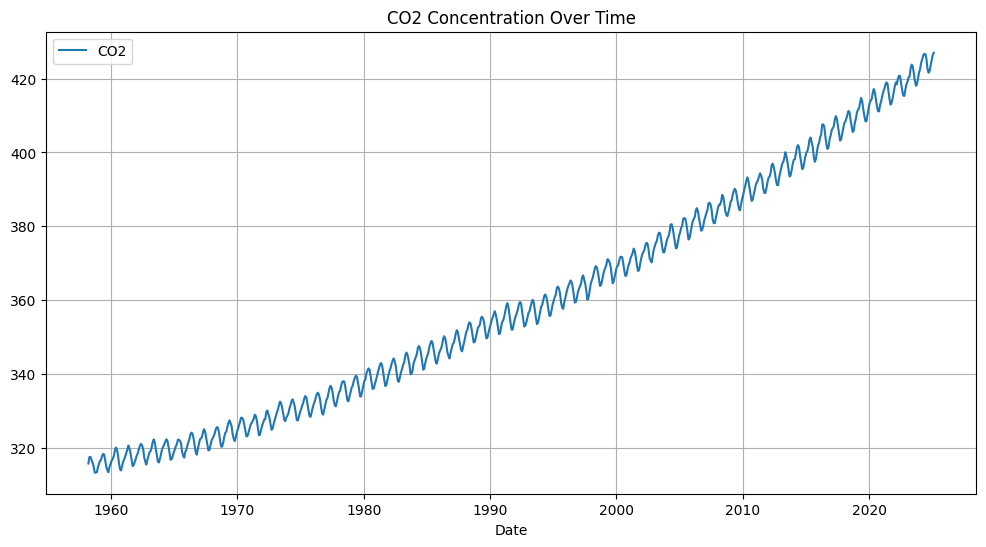

In [28]:
df.plot(x="Date",y="CO2",title="CO2 Concentration Over Time",grid=True,figsize=(12,6),kind="line")

### 日本語の文字の対応

* ベストの手法: japanize-matplotlib

In [29]:
!pip install japanize-matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 19.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize-matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=e56813d0f70616bf58e9cc621964688538fcd4e4478b67eb4a06a4ef9d2c63ae
  Stored in directory: /root/.cache/pip/wheels/da/a1/71/b8faeb93276fed10edffcca20746f1ef6f8d9e071eee8425fc
Successfully built japanize-matplotlib


In [30]:
import japanize_matplotlib

<Axes: title={'center': 'CO2 密度の時系列'}, xlabel='Date'>

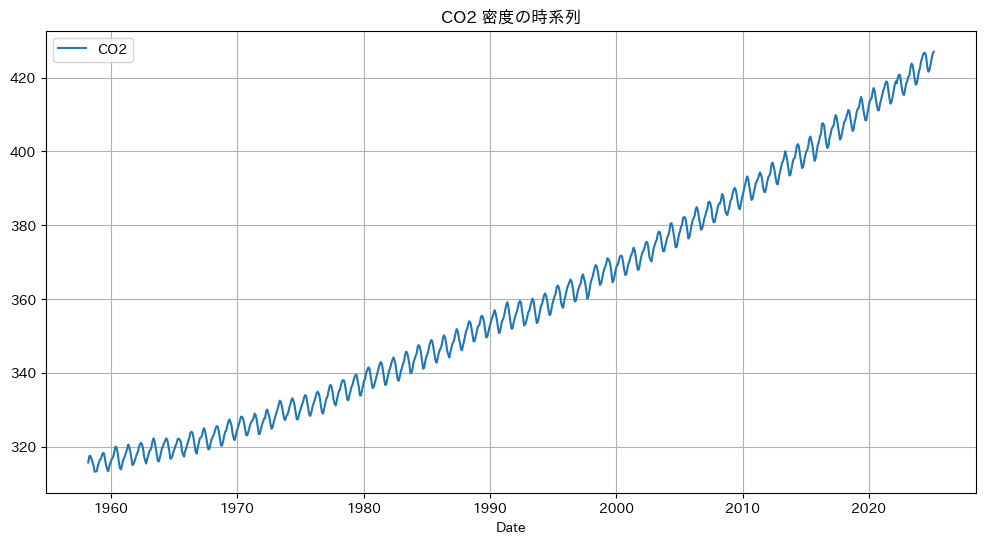

In [31]:
df.plot(x="Date",y="CO2",title="CO2 密度の時系列",grid=True,figsize=(12,6),kind="line")

## Matplotlibの手法

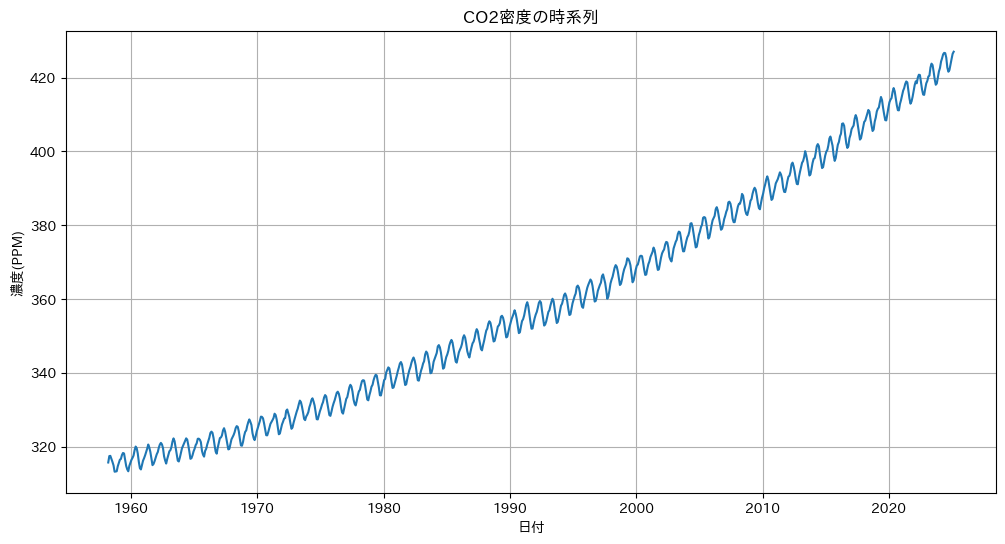

In [35]:

x = df["Date"]
y = df["CO2"]
plt.figure(figsize=(12,6)) #FIGでサイズを設定する
plt.plot(x,y)#プロット
#プロットの他の情報を追加
plt.title("CO2密度の時系列")
plt.xlabel("日付")
plt.ylabel("濃度(PPM)")
plt.grid(True)
plt.show()

In [36]:
df.head()

,Yr,Mn,Date Excel,Date,CO2,seasonally,Year-Mn
2,1958,3,21259,1958.2027,315.71,314.43,1958-3
3,1958,4,21290,1958.2877,317.45,315.15,1958-4
4,1958,5,21320,1958.3699,317.51,314.69,1958-5
6,1958,7,21381,1958.5370,315.87,315.20,1958-7
7,1958,8,21412,1958.6219,314.93,316.23,1958-8


In [38]:
df["Mn"]

,Mn
2,3
3,4
4,5
6,7
7,8
...,...
801,10
802,11
803,12
804,1


In [76]:
use_df = df.copy()
use_df

,Yr,Mn,Date Excel,Date,CO2,seasonally,Year-Mn
Year-Mn,,,,,,,
1958-03-01,1958,3,21259,1958.2027,315.71,314.43,1958-3
1958-04-01,1958,4,21290,1958.2877,317.45,315.15,1958-4
1958-05-01,1958,5,21320,1958.3699,317.51,314.69,1958-5
1958-07-01,1958,7,21381,1958.5370,315.87,315.20,1958-7
1958-08-01,1958,8,21412,1958.6219,314.93,316.23,1958-8
...,...,...,...,...,...,...,...
2024-10-01,2024,10,45580,2024.7896,422.05,425.66,2024-10
2024-11-01,2024,11,45611,2024.8743,423.61,425.87,2024-11
2024-12-01,2024,12,45641,2024.9563,425.00,425.92,2024-12


In [80]:
# Pandas のResample 目的　月の平均の移動
#手法１ DatetimeIndex
#df.index = pd.to_datetime(df["Year-Mn"])
use_df = df.copy()
use_df.index = pd.to_datetime(df["Year-Mn"])
use_df = use_df[df.index>"2000-01-01"]
df_Mn_mean=use_df.groupby("Mn")["CO2"].mean()
df_Mn_std=use_df.groupby("Mn")["CO2"].std()

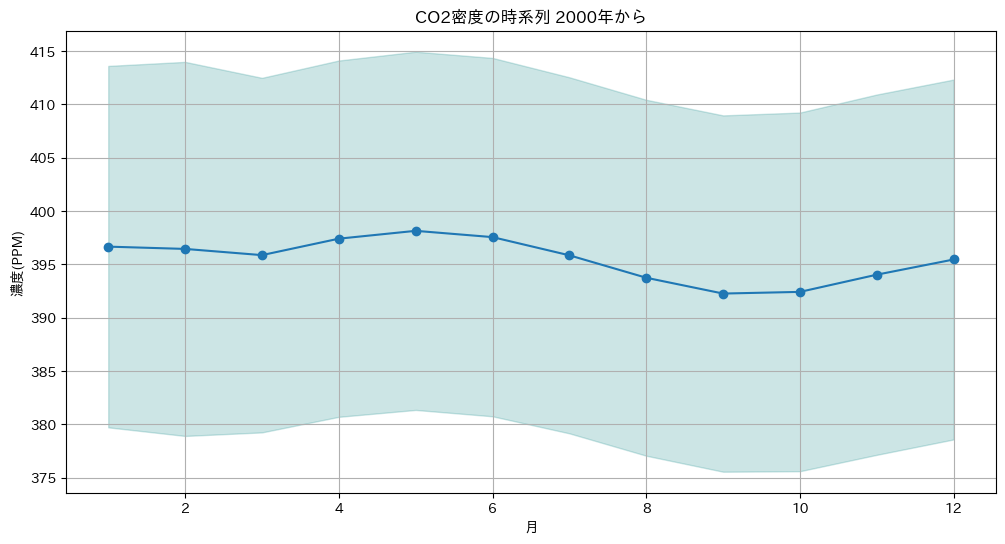

In [97]:
x=np.arange(1,13)
y=df_Mn_mean
y_err=df_Mn_std
plt.figure(figsize=(12,6)) #FIGでサイズを設定する
plt.plot(x,y,label="mean", marker='o')#プロット
plt.fill_between(x, y + y_err, y - y_err, alpha=0.2, color='teal')
#plt.errorbar(x, y, yerr = y_err, capsize=5, fmt='o', markersize=10, ecolor='black', markeredgecolor = "black", color='w')

#プロットの他の情報を追加
plt.title("CO2密度の時系列 2000年から")
plt.xlabel("月")
plt.ylabel("濃度(PPM)")
plt.grid(True)
plt.show()

In [84]:
df_clean

,Yr,Mn,Date Excel,Date,CO2,seasonally,Year-Mn,RollingMean,Residual
Year-Mn,,,,,,,,,
1958-11-01,1958,11,21504,1958.8740,313.33,315.21,1958-11,315.760000,-2.430000
1958-12-01,1958,12,21534,1958.9562,314.67,315.43,1958-12,315.975000,-1.305000
1959-01-01,1959,1,21565,1959.0411,315.58,315.52,1959-1,316.033333,-0.453333
1959-02-01,1959,2,21596,1959.1260,316.49,315.84,1959-2,315.952500,0.537500
1959-03-01,1959,3,21624,1959.2027,316.65,315.37,1959-3,315.862500,0.787500
...,...,...,...,...,...,...,...,...,...
2024-05-01,2024,5,45427,2024.3716,426.70,423.30,2024-5,423.775000,2.925000
2024-06-01,2024,6,45458,2024.4563,426.62,424.06,2024-6,424.066667,2.553333
2024-07-01,2024,7,45488,2024.5383,425.40,424.63,2024-7,424.345833,1.054167


### Box plot

<Figure size 1200x600 with 0 Axes>

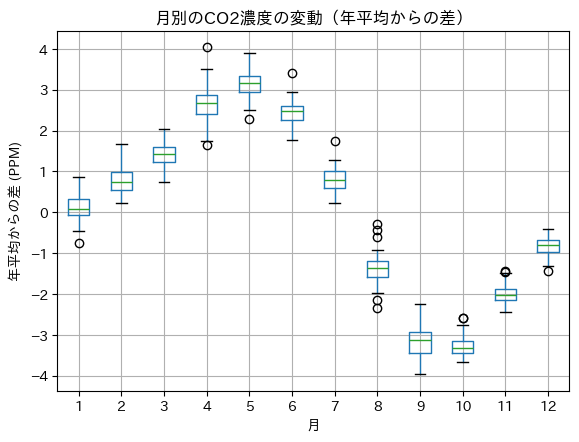

In [85]:
# Rolling 12-month mean
use_df = df.copy()
use_df.index = pd.to_datetime(df["Year-Mn"])
use_df["RollingMean"] = use_df["CO2"].rolling(window=12, center=True).mean()

# Residual = Actual CO2 - Rolling Mean
use_df["Residual"] = use_df["CO2"] - use_df["RollingMean"]

# Drop NaNs caused by rolling
df_clean = use_df.dropna(subset=["Residual"])

# Plot boxplot of residuals grouped by month
plt.figure(figsize=(12, 6))
df_clean.boxplot(column="Residual", by="Mn", grid=True)
plt.title("月別のCO2濃度の変動（年平均からの差）")
plt.suptitle("")  # Remove automatic suptitle
plt.xlabel("月")
plt.ylabel("年平均からの差 (PPM)")
plt.show()

### Linear regression 線形回帰

年間平均の増加率: 1.65 ppm/年


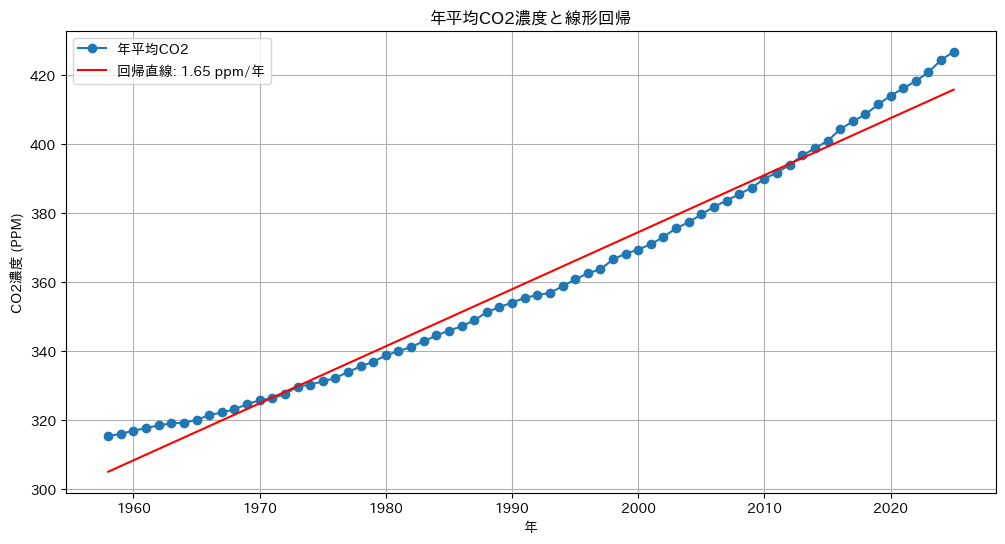

In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Group data by year and get yearly average CO2
use_df=df.copy()
yearly = df.groupby("Yr")["CO2"].mean().reset_index()

# Extract X and Y for regression
X = yearly["Yr"].values
Y = yearly["CO2"].values

# Linear regression using numpy
# Fit line: Y = a * X + b
a, b = np.polyfit(X, Y, 1)  # 1 = linear

# Print the slope
print(f"年間平均の増加率: {a:.2f} ppm/年")

# Optional: Plot it
plt.figure(figsize=(12,6))
plt.plot(X, Y, label="年平均CO2", marker='o')
plt.plot(X, a * X + b, color='red', label=f"回帰直線: {a:.2f} ppm/年")
plt.xlabel("年")
plt.ylabel("CO2濃度 (PPM)")
plt.title("年平均CO2濃度と線形回帰")
plt.legend()
plt.grid(True)
plt.show()

